# Detection de fraude avec arbre de decision

Dans ce notebook, on construit progressivement un premier pipeline de detection de fraude a partir d'un arbre de decision. L'objectif est de comprendre la structure des donnees, preparer un jeu de variables exploitable, puis evaluer si ce modele simple arrive a capter un signal utile.

# 1. Chargement et première inspection des données

Cette premiere etape permet de verifier la taille du dataset, les types de variables, la presence de valeurs manquantes et quelques problemes evidents de qualite des donnees avant de commencer l'analyse.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler

import optuna
from sklearn.model_selection import RandomizedSearchCV

/home/eren/miniconda3/envs/ml-env/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = pd.read_csv('data/Fraud Detection Dataset.csv')

In [3]:
print(f"La taille du dataset est de {df.shape[0]} lignes et {df.shape[1]} colonnes")

La taille du dataset est de 51000 lignes et 12 colonnes


In [4]:
print("Les informations sur les données :")
df.info()

Les informations sur les données :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51000 entries, 0 to 50999
Data columns (total 12 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Transaction_ID                    51000 non-null  object 
 1   User_ID                           51000 non-null  int64  
 2   Transaction_Amount                48480 non-null  float64
 3   Transaction_Type                  51000 non-null  object 
 4   Time_of_Transaction               48448 non-null  float64
 5   Device_Used                       48527 non-null  object 
 6   Location                          48453 non-null  object 
 7   Previous_Fraudulent_Transactions  51000 non-null  int64  
 8   Account_Age                       51000 non-null  int64  
 9   Number_of_Transactions_Last_24H   51000 non-null  int64  
 10  Payment_Method                    48531 non-null  object 
 11  Fraudulent                      

On remarque deja que :
- certaines colonnes contiennent des valeurs manquantes, donc une etape de traitement sera necessaire ;
- le dataset melange des variables numeriques et des variables categorielles ;
- la cible `Fraudulent` est binaire, ce qui confirme qu'il s'agit d'un probleme de classification.

In [5]:
# visulisation des premières lignes du dataset
df.head()

,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent
0,T1,4174,1292.76,ATM Withdrawal,16.0,Tablet,San Francisco,0,119,13,Debit Card,0
1,T2,4507,1554.58,ATM Withdrawal,13.0,Mobile,New York,4,79,3,Credit Card,0
2,T3,1860,2395.02,ATM Withdrawal,NaN,Mobile,NaN,3,115,9,NaN,0
3,T4,2294,100.10,Bill Payment,15.0,Desktop,Chicago,4,3,4,UPI,0
4,T5,2130,1490.50,POS Payment,19.0,Mobile,San Francisco,2,57,7,Credit Card,0


In [6]:
# Résumé des varaibles numériques
print("Résumé des variables numériques :")
df.describe().T

Résumé des variables numériques :


,count,mean,std,min,25%,50%,75%,max
User_ID,51000.0,3005.110176,1153.121107,1000.00,2007.0000,2996.0,4006.00,4999.0
Transaction_Amount,48480.0,2996.249784,5043.932555,5.03,1270.5525,2524.1,3787.24,49997.8
Time_of_Transaction,48448.0,11.488400,6.922954,0.00,5.0000,12.0,17.00,23.0
Previous_Fraudulent_Transactions,51000.0,1.995725,1.415150,0.00,1.0000,2.0,3.00,4.0
Account_Age,51000.0,60.033902,34.384131,1.00,30.0000,60.0,90.00,119.0
Number_of_Transactions_Last_24H,51000.0,7.495588,4.020080,1.00,4.0000,7.0,11.00,14.0
Fraudulent,51000.0,0.049216,0.216320,0.00,0.0000,0.0,0.00,1.0


> Les variables numeriques n'ont pas la meme echelle. Donc on va essayer de les normaliser à l'étape du prétraitement

In [7]:
# vérification des valeurs manquantes
print("Vérification des valeurs manquantes :")
print(df.isnull().sum())

Vérification des valeurs manquantes :
Transaction_ID                         0
User_ID                                0
Transaction_Amount                  2520
Transaction_Type                       0
Time_of_Transaction                 2552
Device_Used                         2473
Location                            2547
Previous_Fraudulent_Transactions       0
Account_Age                            0
Number_of_Transactions_Last_24H        0
Payment_Method                      2469
Fraudulent                             0
dtype: int64


In [8]:
# verification des doublons
print("Vérification des doublons :")
print(f"Nombre de doublons : {df.duplicated().sum()}")

Vérification des doublons :
Nombre de doublons : 881


# 2. Analyse exploratoire des données (EDA)

> L'objectif ici est de mieux comprendre les distributions, les ordres de grandeur, les eventuelles anomalies et les relations entre variables afin d'orienter les choix de nettoyage et de modelisation.

## Analyse univariee

On commence par observer chaque variable prise isolement pour reperer les asymetries, les valeurs extremes et la nature des differentes colonnes.

### Variables numeriques

Les boxplots ci-dessous permettent de visualiser la dispersion des variables et la presence eventuelle de valeurs tres eloignees du coeur de distribution.

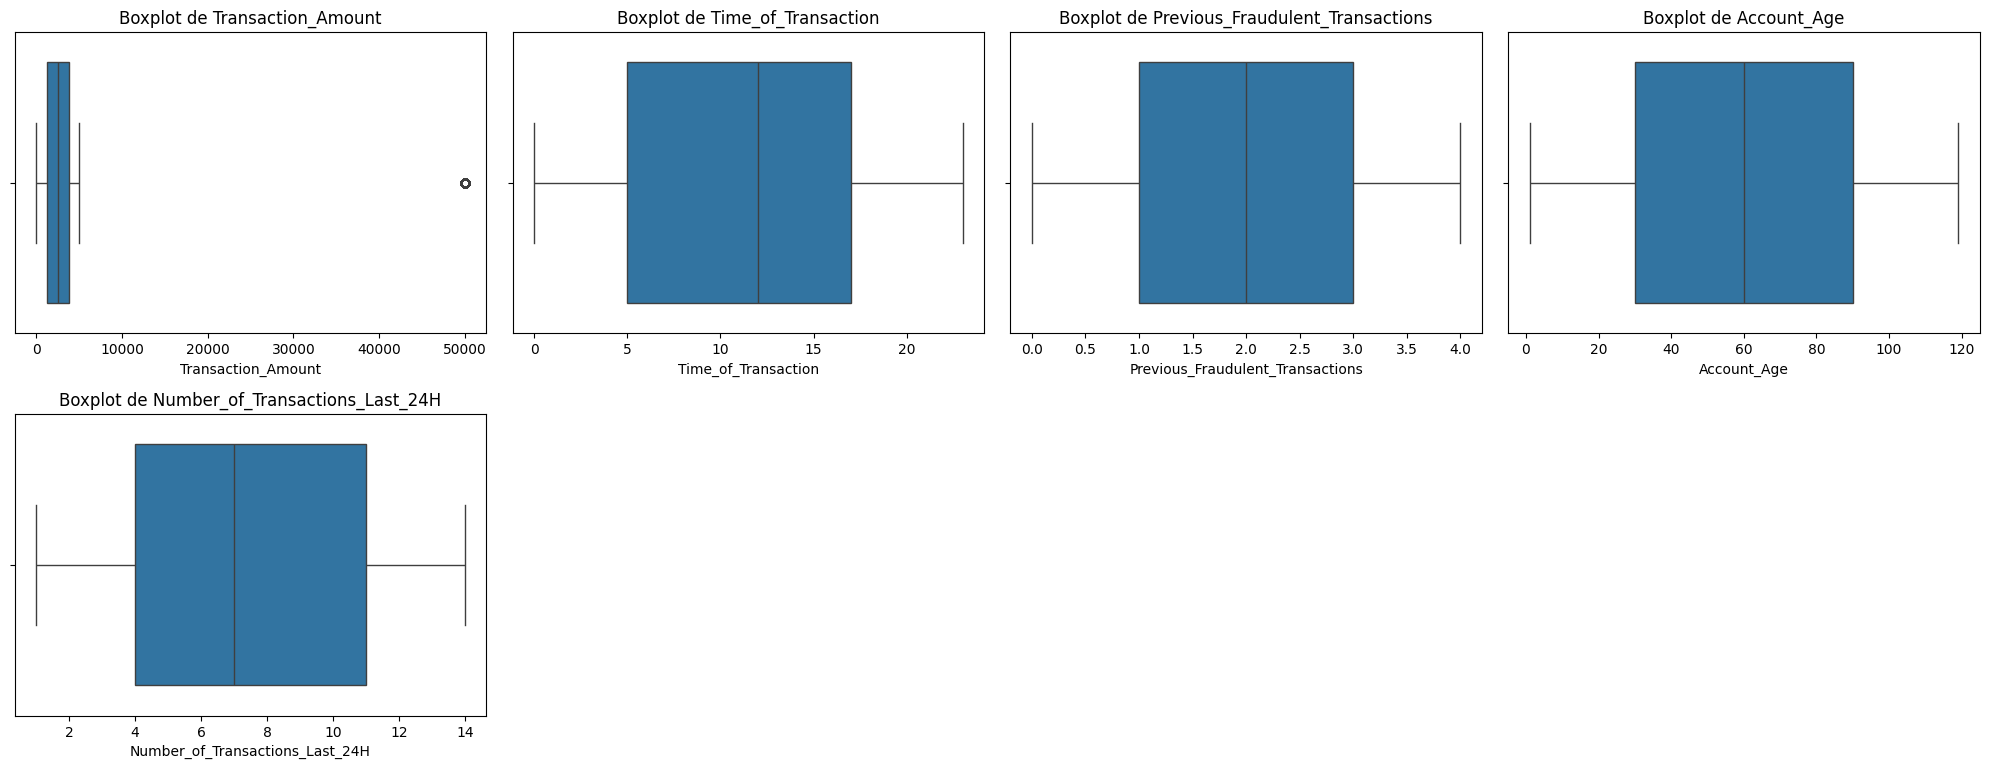

In [9]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
num_cols.remove('Fraudulent')  # Exclure la variable cible
num_cols.remove('User_ID')  # Exclure l'identifiant de l'utilisateur

plt.figure(figsize=(20, 15))
for i, col in enumerate(num_cols):
    plt.subplot(4, 4, i + 1)
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot de {col}')
plt.tight_layout()
plt.show()

In [10]:
# Nomnbre de transactions avec un montant supérieur à 40000 (les outliers)'
(df["Transaction_Amount"] > 40000).sum()

np.int64(508)

> La variable `Transaction_Amount` presente des valeurs elevees par rapport au reste de la distribution. On peut les considerer comme des valeurs extremes, mais pas automatiquement comme des valeurs aberrantes.

### Variables categorielles

Cette partie sert a examiner la repartition des modalites et a reperer d'eventuelles categories rares ou atypiques.

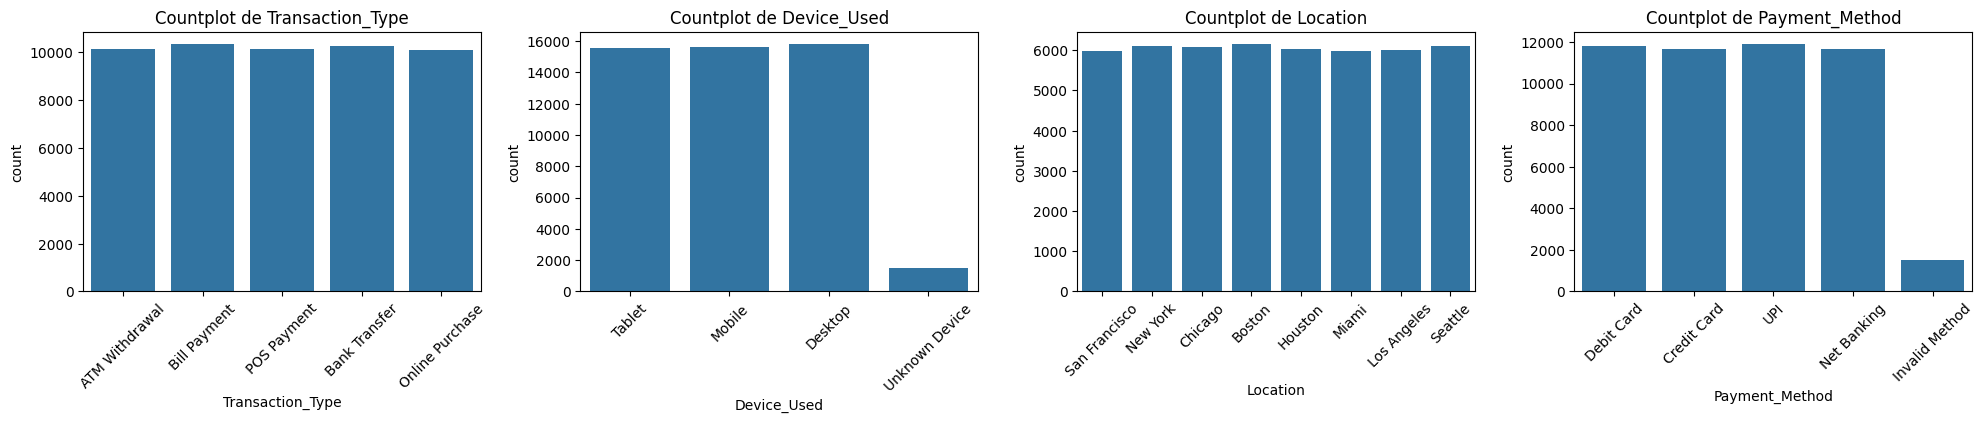

In [11]:
cat_cols = df.select_dtypes(include=['object']).columns.to_list()
cat_cols.remove('Transaction_ID')  # Exclure l'identifiant de transaction

plt.figure(figsize=(20, 15))
for i, col in enumerate(cat_cols):
    plt.subplot(4, 4, i + 1)
    sns.countplot(x=df[col])
    plt.title(f'Countplot de {col}')
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Analyse bivariee

On etudie maintenant la relation entre les variables explicatives et la cible afin d'identifier les colonnes potentiellement informatives.

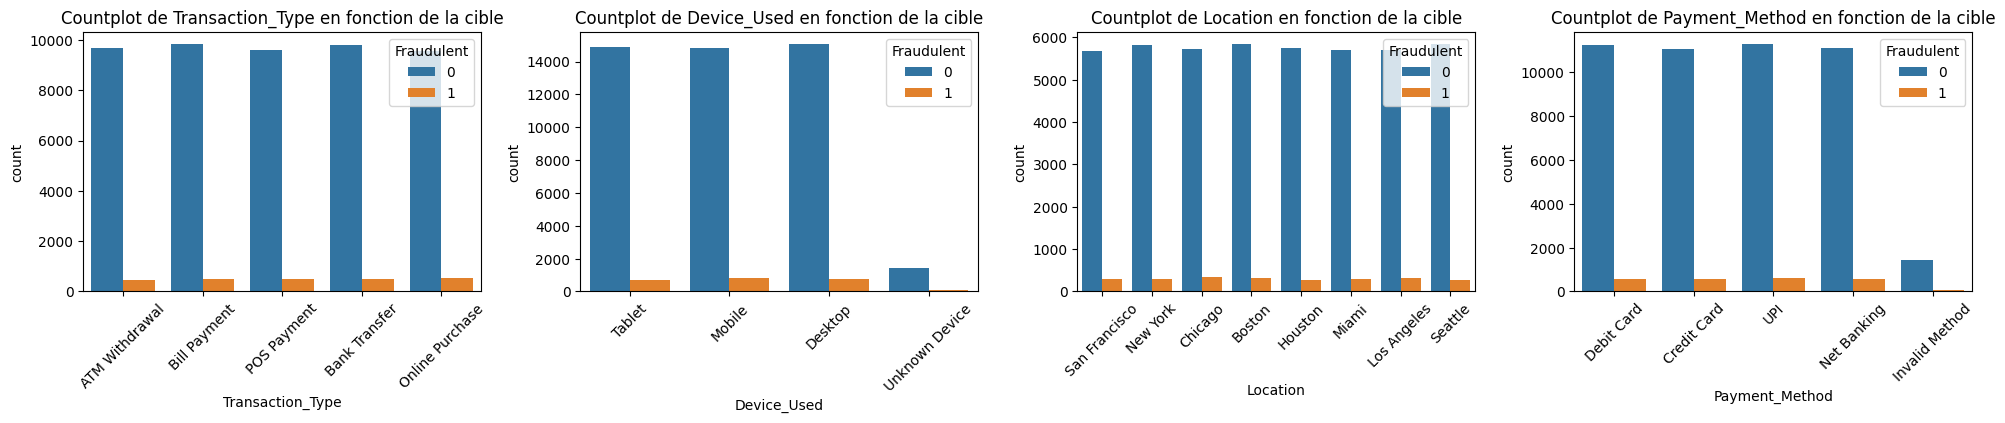

In [12]:
# analyse bivariée entre les variables catégorielles et la cible
plt.figure(figsize=(20, 15))
for i, col in enumerate(cat_cols):
    plt.subplot(4, 4, i + 1)
    sns.countplot(x=df[col], hue=df['Fraudulent'])
    plt.title(f'Countplot de {col} en fonction de la cible')
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

> On observe visuellement un desequilibre de classes : la classe non frauduleuse domine la classe frauduleuse dans la plupart des categories.

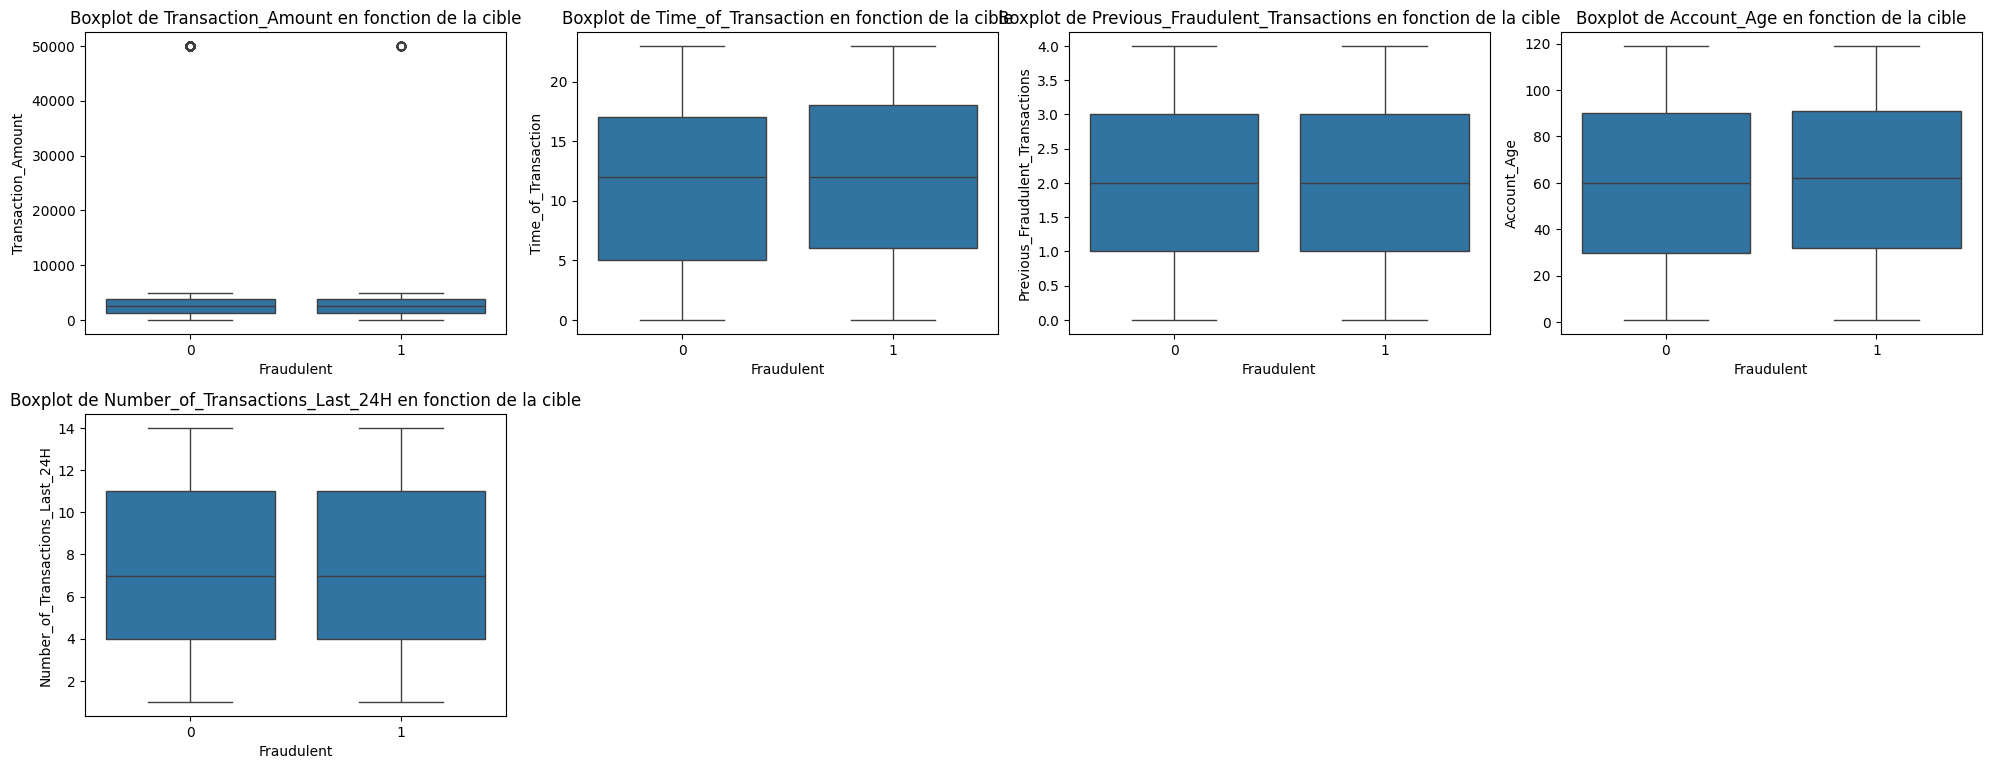

In [13]:
# analyse bivariée entre les variables numériques et la cible
plt.figure(figsize=(20, 15))
for i, col in enumerate(num_cols):
    plt.subplot(4, 4, i + 1)
    sns.boxplot(x=df['Fraudulent'], y=df[col])
    plt.title(f'Boxplot de {col} en fonction de la cible')
plt.tight_layout()
plt.show()

> On observe que les boxplots se ressemble pour les deux classes de la clible, un modele simple n'arrivera peut être pas à distinguer les deux classes

## Correlations

La matrice de correlation permet d'examiner les relations lineaires entre variables numeriques et de voir si certaines colonnes evoluent ensemble.

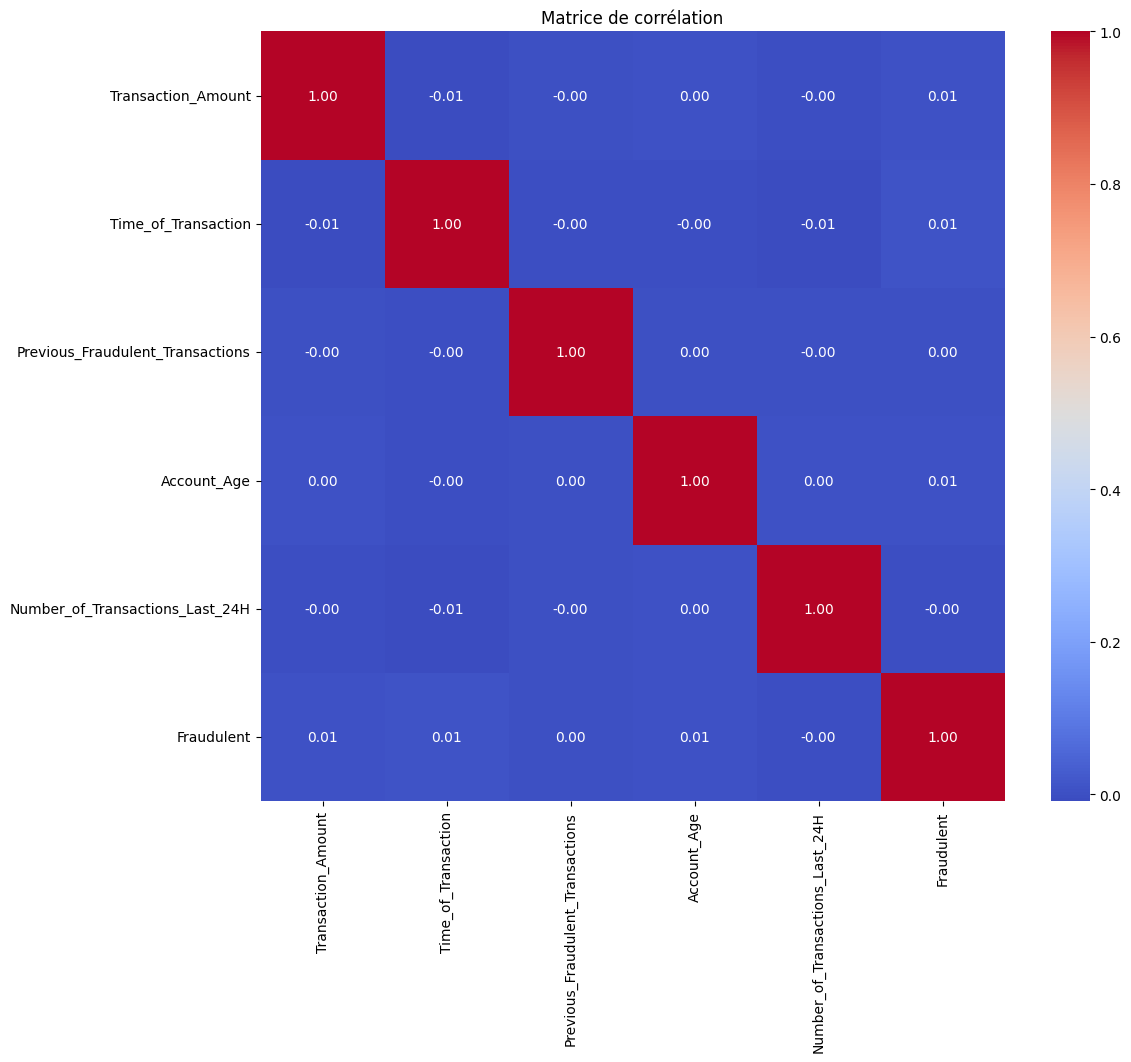

In [14]:
# matrice de corrélation entre les variables numériques et la cible
corr = df[num_cols + ['Fraudulent']].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matrice de corrélation')
plt.show()

> Les correlations sont faibles. Cela signifie qu'il n'y a pas de relation lineaire forte entre les variables.

## Desequilibre des classes

Avant d'entrainer le modele, il est important de verifier la repartition de la cible, car un fort desequilibre peut biaiser l'evaluation.

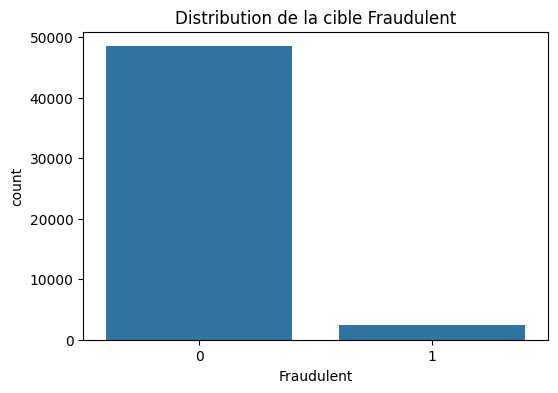

In [15]:
# distribution de la cible
plt.figure(figsize=(6, 4))
sns.countplot(x=df['Fraudulent'])
plt.title('Distribution de la cible Fraudulent')
plt.show()

### Interpretation

La cible est fortement desequilibree. Cela implique deux consequences pratiques :
- il faut utiliser `stratify=y` lors de la separation train/test pour conserver des proportions comparables ;
- l'accuracy seule sera peu informative, donc il faut privilegier des metriques comme l'AUC, la precision, le rappel ou la matrice de confusion.

# 3. Nettoyage et prétraitement des données

> Dans cette section, on prepare les donnees pour l'apprentissage : suppression des doublons, traitement des valeurs manquantes, encodage des variables categorielles et creation de nouvelles variables.

## Gestion des doublons

La suppression des doublons evite de surrepresenter certaines observations et limite un eventuel biais dans l'apprentissage.

In [16]:
# supppresion des doublons
df = df.drop_duplicates()
print(f"Nombre de doublons après suppression : {df.duplicated().sum()}")
print(f"Taille du dataset après suppression des doublons : {df.shape[0]} lignes et {df.shape[1]} colonnes")

Nombre de doublons après suppression : 0
Taille du dataset après suppression des doublons : 50119 lignes et 12 colonnes


## Gestion des valeurs manquantes

On remplace ici les valeurs manquantes avec des regles simples et interpretable : la mediane pour le numerique et le mode pour le categoriel.

In [17]:
# Imputation des valeurs manquantes pour les variables catégorielles
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Imputation des valeurs manquantes pour les variables numériques
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())


print("Vérification des valeurs manquantes après imputation :")
print(df.isnull().sum())

Vérification des valeurs manquantes après imputation :
Transaction_ID                      0
User_ID                             0
Transaction_Amount                  0
Transaction_Type                    0
Time_of_Transaction                 0
Device_Used                         0
Location                            0
Previous_Fraudulent_Transactions    0
Account_Age                         0
Number_of_Transactions_Last_24H     0
Payment_Method                      0
Fraudulent                          0
dtype: int64


## Encodage des variables categorielles

Les algorithmes de scikit-learn attendent des entrees numeriques. Il faut donc transformer les modalites textuelles en colonnes binaires.

In [18]:
print(cat_cols)

['Transaction_Type', 'Device_Used', 'Location', 'Payment_Method']


> Ces variables sont nominales, c'est-a-dire sans ordre naturel entre les modalites. Le one-hot encoding est donc un choix adapte pour ne pas introduire de hierarchie artificielle.

In [19]:
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)
df_encoded.head()

,Transaction_ID,User_ID,Transaction_Amount,Time_of_Transaction,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Fraudulent,Transaction_Type_Bank Transfer,Transaction_Type_Bill Payment,...,Location_Houston,Location_Los Angeles,Location_Miami,Location_New York,Location_San Francisco,Location_Seattle,Payment_Method_Debit Card,Payment_Method_Invalid Method,Payment_Method_Net Banking,Payment_Method_UPI
0,T1,4174,1292.76,16.0,0,119,13,0,False,False,...,False,False,False,False,True,False,True,False,False,False
1,T2,4507,1554.58,13.0,4,79,3,0,False,False,...,False,False,False,True,False,False,False,False,False,False
2,T3,1860,2395.02,12.0,3,115,9,0,False,False,...,False,False,False,False,False,False,False,False,False,True
3,T4,2294,100.10,15.0,4,3,4,0,False,True,...,False,False,False,False,False,False,False,False,False,True
4,T5,2130,1490.50,19.0,2,57,7,0,False,False,...,False,False,False,False,True,False,False,False,False,False


## Standardisation des variables numeriques

On met ici les variables numeriques sur une echelle comparable.

In [20]:
# Normalisation des variables numériques

scaler = StandardScaler()
df_encoded[num_cols] = scaler.fit_transform(df_encoded[num_cols])
df_encoded.head()

,Transaction_ID,User_ID,Transaction_Amount,Time_of_Transaction,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Fraudulent,Transaction_Type_Bank Transfer,Transaction_Type_Bill Payment,...,Location_Houston,Location_Los Angeles,Location_Miami,Location_New York,Location_San Francisco,Location_Seattle,Payment_Method_Debit Card,Payment_Method_Invalid Method,Payment_Method_Net Banking,Payment_Method_UPI
0,T1,4174,-0.340960,0.664877,-1.410441,1.714659,1.369323,0,False,False,...,False,False,False,False,True,False,True,False,False,False
1,T2,4507,-0.287913,0.220229,1.415459,0.551605,-1.118384,0,False,False,...,False,False,False,True,False,False,False,False,False,False
2,T3,1860,-0.117633,0.072013,0.708984,1.598353,0.374241,0,False,False,...,False,False,False,False,False,False,False,False,False,True
3,T4,2294,-0.582603,0.516661,1.415459,-1.658197,-0.869613,0,False,True,...,False,False,False,False,False,False,False,False,False,True
4,T5,2130,-0.300896,1.109525,0.002509,-0.088074,-0.123301,0,False,False,...,False,False,False,False,True,False,False,False,False,False


## Feature engineering

On cree quelques variables derivees pour essayer de rendre plus explicites certains comportements potentiellement suspects, par exemple des rapports entre montant, anciennete du compte et activite recente.

In [21]:
# Calcul sur les valeurs originales (non normalisées) pour des ratios cohérents
df["amount_ratio"] = df["Transaction_Amount"] / df["Number_of_Transactions_Last_24H"]
df["fraud_ratio"] = df["Previous_Fraudulent_Transactions"] / df["Account_Age"]
df["montant_age_compte"] = df["Transaction_Amount"] / df["Account_Age"]

# Ajout à df_encoded
new_features = ["amount_ratio", "fraud_ratio", "montant_age_compte"]
for feat in new_features:
    df_encoded[feat] = df[feat]

# Normalisation des nouvelles features
df_encoded[new_features] = StandardScaler().fit_transform(df_encoded[new_features])

## Construction du jeu de variables

A cette etape, on separe les variables explicatives `X` de la cible `y`, puis on retire les identifiants.

In [22]:
X = df_encoded.drop(columns=["Transaction_ID", "User_ID", "Fraudulent"])
y = df_encoded['Fraudulent']

## Decoupage en jeux d'entrainement et de test

On separe ensuite les donnees pour pouvoir entrainer le modele sur un sous-ensemble et mesurer sa capacite de generalisation sur des observations non vues.

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [24]:
# Pour dessiner les metriques d'évaluation

def plot_auc_and_confusion(model, X_eval, y_eval, model_name):
    y_pred = model.predict(X_eval)
    y_proba = model.predict_proba(X_eval)[:, 1]
    auc_score = roc_auc_score(y_eval, y_proba)
    fpr, tpr, _ = roc_curve(y_eval, y_proba)
    cm = confusion_matrix(y_eval, y_pred)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(fpr, tpr, label=f'AUC = {auc_score:.4f}', color='darkorange', linewidth=2)
    axes[0].plot([0, 1], [0, 1], linestyle='--', color='navy')
    axes[0].set_title(f'Courbe ROC - {model_name}')
    axes[0].set_xlabel('False Positive Rate')
    axes[0].set_ylabel('True Positive Rate')
    axes[0].legend(loc='lower right')

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[1])
    axes[1].set_title(f'Matrice de confusion - {model_name}')
    axes[1].set_xlabel('Prediction')
    axes[1].set_ylabel('Reel')
    axes[1].set_xticklabels(['Non fraude', 'Fraude'])
    axes[1].set_yticklabels(['Non fraude', 'Fraude'])

    plt.tight_layout()
    plt.show()
    print(f'AUC score {model_name} : {auc_score:.4f}')
    return auc_score

def draw_tree_model(model, feature_names, model_name, max_depth=3):
    plt.figure(figsize=(24, 12))
    plot_tree(
        model,
        feature_names=feature_names,
        class_names=['Non fraude', 'Fraude'],
        filled=True,
        rounded=True,
        max_depth=max_depth,
        fontsize=8
    )
    plt.title(f"Visualisation de l'arbre - {model_name} (profondeur affichee = {max_depth})")
    plt.show()

# 4. Le modèle de base
> Cette premiere version sert de point de comparaison. elle donne une reference utile avant de chercher a ajuster les hyperparametres.

In [25]:
# random_state fixe la graine pour obtenir les memes resultats a chaque execution.
baseline_simple = DecisionTreeClassifier(random_state=42)

In [26]:
# Entrainement du model
baseline_simple.fit(X_train, y_train)

# prediction sur le test
y_pred_proba_baseline = baseline_simple.predict_proba(X_test)[:, 1]
y_pred_proba_baseline

array([0., 1., 1., ..., 1., 0., 0.], shape=(10024,))

AUC score baseline : 0.4997


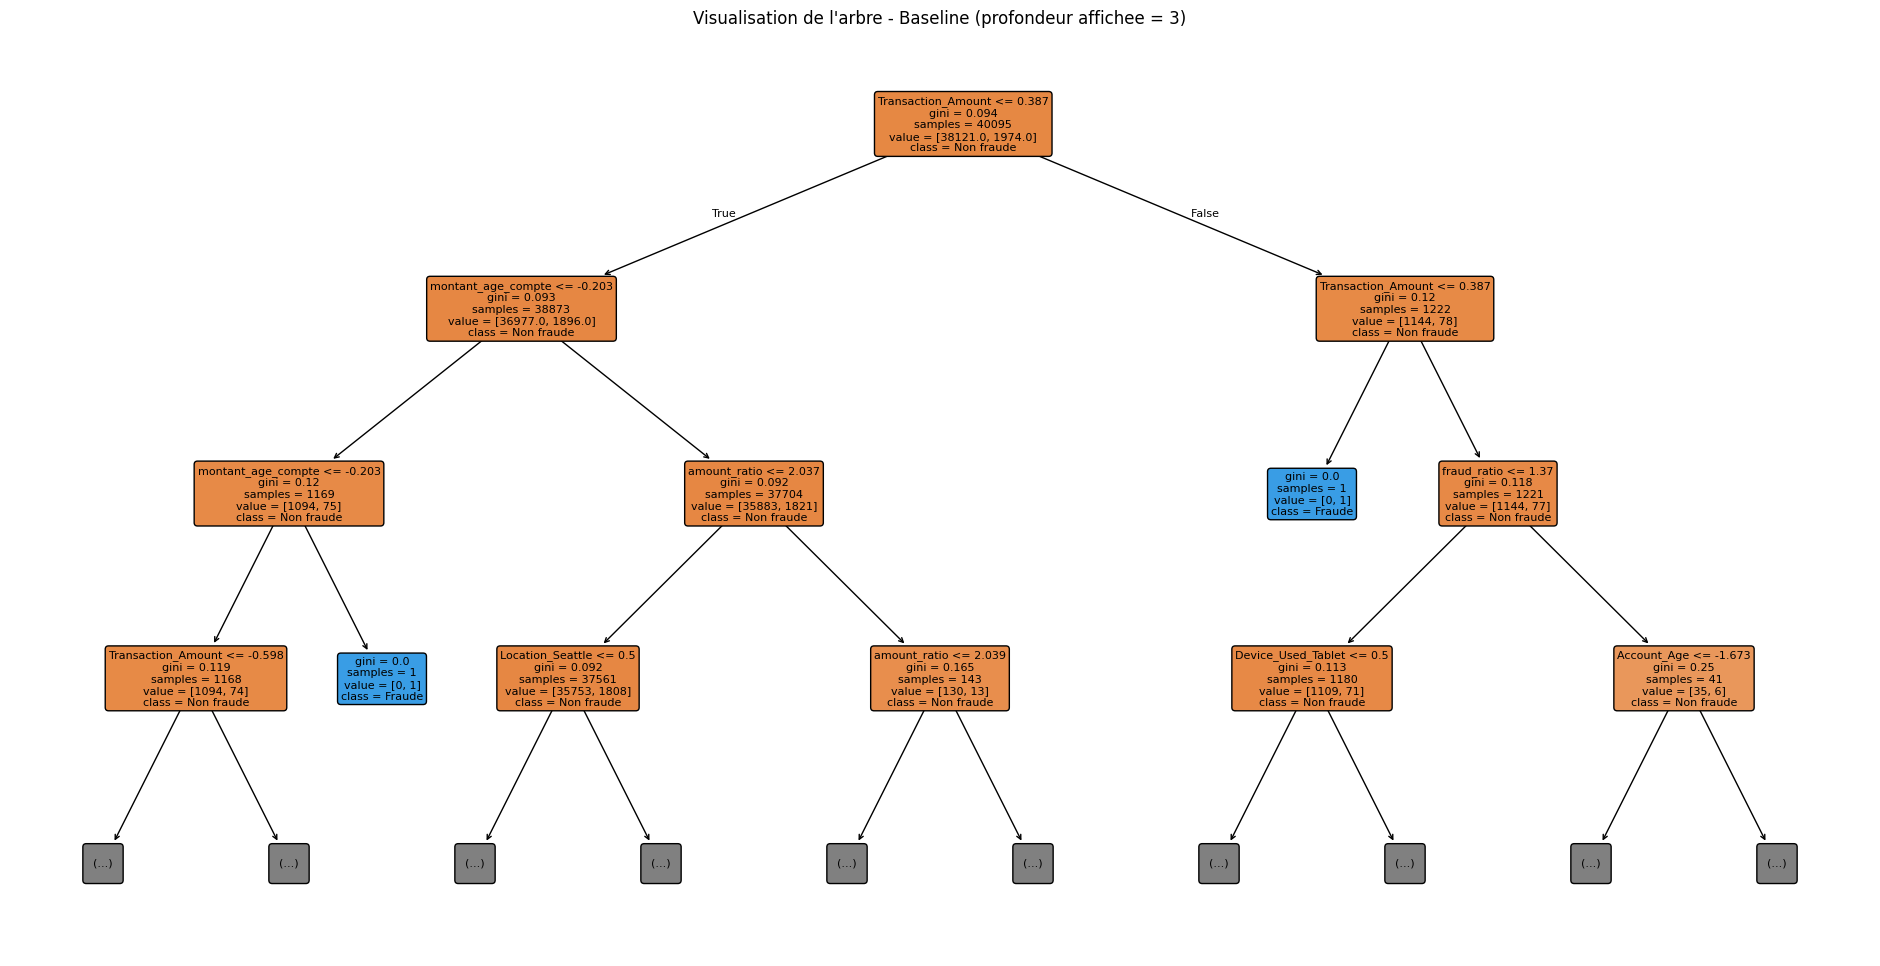

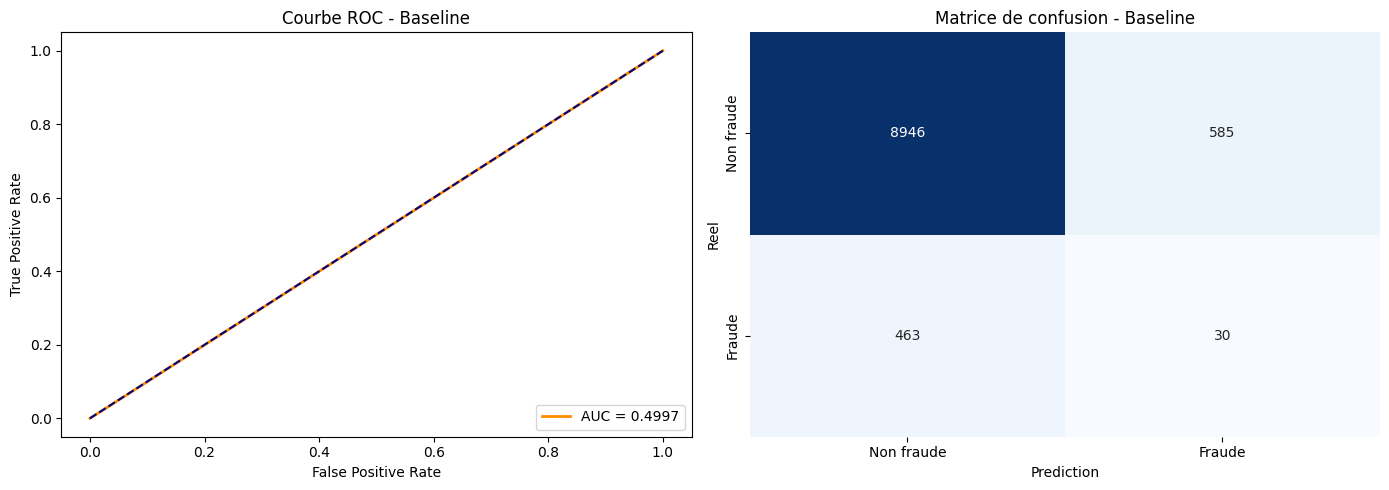

AUC score Baseline : 0.4997


0.49973663393265877

In [27]:
# Evaluation du model
auc_baseline = roc_auc_score(y_test, y_pred_proba_baseline)
print(f"AUC score baseline : {auc_baseline:.4f}")
draw_tree_model(baseline_simple, X_train.columns, "Baseline", max_depth=3)
plot_auc_and_confusion(baseline_simple, X_test, y_test, "Baseline")

> L'AUC obtenue est tres proche de 0.5, ce qui suggere que ce modele de base distingue mal les transactions frauduleuses des transactions non frauduleuses. ce qui confirme mon hypothèse lors de l'analyse des boxplots.
On va  tester si un reequilibrage des classes et un meilleur reglage de l'arbre peuvent ameliorer la situation.

In [28]:
# random_state fixe la graine pour obtenir les memes resultats a chaque execution.
# class_weight='balanced' donne plus de poids a la classe minoritaire.
baseline_balanced = DecisionTreeClassifier(random_state=42, class_weight='balanced')

In [29]:
# Entrainement du model
baseline_balanced.fit(X_train, y_train)

# prediction sur le test
y_pred_proba_balanced = baseline_balanced.predict_proba(X_test)[:, 1]
y_pred_proba_balanced

array([0., 0., 0., ..., 0., 0., 0.], shape=(10024,))

AUC score baseline (class_weight='balanced') : 0.5024


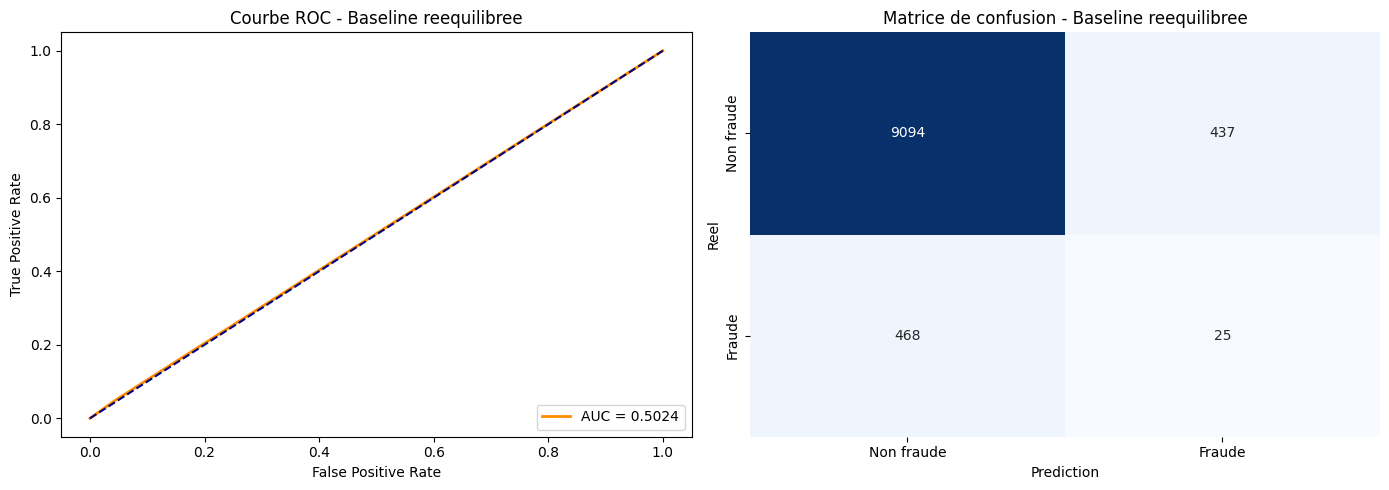

AUC score Baseline reequilibree : 0.5024


0.5024297780936042

In [30]:
auc_baseline_balanced = roc_auc_score(y_test, y_pred_proba_balanced)
print(f"AUC score baseline (class_weight='balanced') : {auc_baseline_balanced:.4f}")
plot_auc_and_confusion(baseline_balanced, X_test, y_test, "Baseline reequilibree")

Le modele de base etant peu performant, on passe maintenant a une phase d'optimisation pour chercher une meilleure combinaison d'hyperparametres.

# 5. Optimisation des hyperparametres

L'objectif ici est d'explorer plusieurs structures d'arbres afin d'identifier un compromis plus interessant entre biais, variance et prise en compte du desequilibre.

## Utilisation de RandomizedSearchCV

Plutot que de tester exhaustivement toutes les combinaisons possibles, on echantillonne un certain nombre de configurations de maniere aleatoire pour gagner du temps de calcul.

In [31]:
# Grille de parametres a tester avec Randomized.
params_grid = {
    "criterion": ["gini", "entropy", "log_loss"],  # mesure la qualite d'une separation
    "splitter": ["best", "random"],  # choisit la meilleure coupure ou une coupure aleatoire
    "max_depth": [3, 5, 7, 10, 15, 20, None],  # limite la profondeur de l'arbre
    "min_samples_split": [2, 5, 10, 20],  # nombre minimal d'exemples pour diviser un noeud
    "min_samples_leaf": [1, 5, 10, 20, 50],  # nombre minimal d'exemples dans une feuille
    "max_features": [None, "sqrt", "log2"],  # nombre de variables considerees a chaque split
    "class_weight": ["balanced", None],  # reequilibre ou non les classes pendant l'apprentissage
    "random_state": [42]  # fixe la graine pour des essais reproductibles
}

In [32]:
n_entrainement = 1
for param in params_grid:
    n_entrainement *= len(params_grid[param])

print(f"Avec GridSearchCV on aura: {n_entrainement} entrainement fois le nombre de fold defini")

Avec GridSearchCV on aura: 5040 entrainement fois le nombre de fold defini


> Ici, on fixe `n_iter = 200`, ce qui permet d'explorer une partie representative de l'espace des hyperparametres sans supporter le cout d'une recherche exhaustive.

In [33]:
model = DecisionTreeClassifier()

random_grid = RandomizedSearchCV(estimator=model, param_distributions=params_grid, n_iter=200, cv=5, scoring='roc_auc', n_jobs=-1, verbose=2)

random_grid.fit(X_train, y_train)

Fitting 5 folds for each of 200 candidates, totalling 1000 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeClassifier()
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'class_weight': ['balanced', None], 'criterion': ['gini', 'entropy', ...], 'max_depth': [3, 5, ...], 'max_features': [None, 'sqrt', ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",200
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be use

Meilleurs paramètres : {'splitter': 'random', 'random_state': 42, 'min_samples_split': 2, 'min_samples_leaf': 20, 'max_features': None, 'max_depth': 15, 'criterion': 'log_loss', 'class_weight': 'balanced'}
AUC : 0.4726


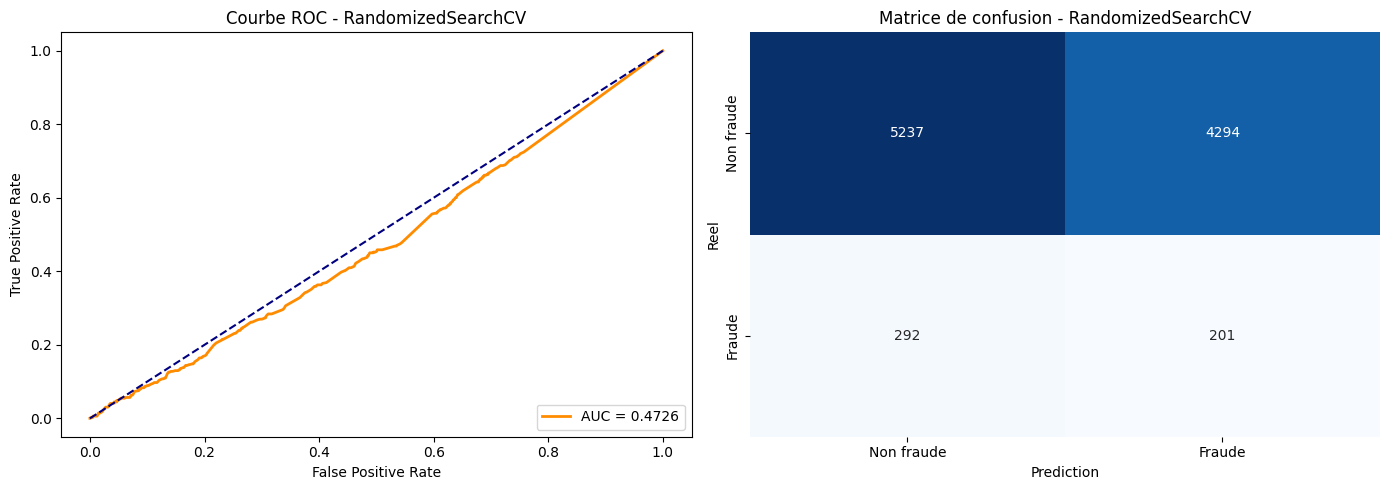

AUC score RandomizedSearchCV : 0.4726


0.472601203332863

In [34]:
y_pred_proba_randomized = random_grid.predict_proba(X_test)[:, 1]
auc_randomized = roc_auc_score(y_test, y_pred_proba_randomized)

print(f"Meilleurs paramètres : {random_grid.best_params_}")
print(f"AUC : {auc_randomized:.4f}")
plot_auc_and_confusion(random_grid.best_estimator_, X_test, y_test, "RandomizedSearchCV")

### Utilisation d'Optuna

On teste aussi une approche d'optimisation bayesienne avec Optuna, qui peut orienter la recherche vers les zones les plus prometteuses de l'espace des hyperparametres.

In [35]:
# Fonction objectif pour Optuna : on maximise le score AUC moyen en validation croisee.
def objective(trial):
    # Optuna propose ici une combinaison d'hyperparametres a tester.
    params = {
        "criterion": trial.suggest_categorical("criterion", ["gini", "entropy", "log_loss"]),
        "splitter": trial.suggest_categorical("splitter", ["best", "random"]),
        "max_depth": trial.suggest_categorical("max_depth", [3, 5, 7, 10, 15, 20, None]),
        "min_samples_split": trial.suggest_categorical("min_samples_split", [2, 5, 10, 20]),
        "min_samples_leaf": trial.suggest_categorical("min_samples_leaf", [1, 5, 10, 20, 50]),
        "max_features": trial.suggest_categorical("max_features", [None, "sqrt", "log2"]),
        "class_weight": trial.suggest_categorical("class_weight", ["balanced", None]),
        "random_state": 42
    }

    model = DecisionTreeClassifier(**params)

    # Validation croisee stratifiee
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    # On calcule l'AUC sur chaque fold puis on prend la moyenne.
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="roc_auc")

    # Calcul du score moyen à maximiserr.
    return scores.mean()

sampler = optuna.samplers.TPESampler(seed=42)
study = optuna.create_study(direction='maximize', sampler=sampler)
study.optimize(objective, n_trials=50, show_progress_bar=True)  # n_trials = nombre de combinaisons testees

optuna_best_params = study.best_params
optuna_best_cv_auc = study.best_value

[I 2026-04-28 11:12:48,217] A new study created in memory with name: no-name-99242296-ae71-4b0a-abae-c8db33542b2a
Best trial: 1. Best value: 0.490768:   4%|▍         | 2/50 [00:00<00:11,  4.22it/s]

[I 2026-04-28 11:12:48,588] Trial 0 finished with value: 0.4856207747996226 and parameters: {'criterion': 'entropy', 'splitter': 'best', 'max_depth': None, 'min_samples_split': 2, 'min_samples_leaf': 50, 'max_features': 'log2', 'class_weight': None}. Best is trial 0 with value: 0.4856207747996226.
[I 2026-04-28 11:12:48,731] Trial 1 finished with value: 0.4907678683082488 and parameters: {'criterion': 'log_loss', 'splitter': 'random', 'max_depth': 10, 'min_samples_split': 2, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'class_weight': 'balanced'}. Best is trial 1 with value: 0.4907678683082488.


Best trial: 2. Best value: 0.496587:   6%|▌         | 3/50 [00:02<00:44,  1.06it/s]

[I 2026-04-28 11:12:50,510] Trial 2 finished with value: 0.496587303909329 and parameters: {'criterion': 'gini', 'splitter': 'best', 'max_depth': 20, 'min_samples_split': 20, 'min_samples_leaf': 5, 'max_features': None, 'class_weight': 'balanced'}. Best is trial 2 with value: 0.496587303909329.


Best trial: 2. Best value: 0.496587:   8%|▊         | 4/50 [00:02<00:32,  1.42it/s]

[I 2026-04-28 11:12:50,857] Trial 3 finished with value: 0.4955169517747414 and parameters: {'criterion': 'log_loss', 'splitter': 'best', 'max_depth': 20, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'log2', 'class_weight': None}. Best is trial 2 with value: 0.496587303909329.


Best trial: 5. Best value: 0.498117:  12%|█▏        | 6/50 [00:02<00:17,  2.55it/s]

[I 2026-04-28 11:12:51,079] Trial 4 finished with value: 0.49126779092861766 and parameters: {'criterion': 'gini', 'splitter': 'best', 'max_depth': 10, 'min_samples_split': 10, 'min_samples_leaf': 5, 'max_features': 'log2', 'class_weight': None}. Best is trial 2 with value: 0.496587303909329.
[I 2026-04-28 11:12:51,200] Trial 5 finished with value: 0.4981170159195057 and parameters: {'criterion': 'gini', 'splitter': 'random', 'max_depth': 15, 'min_samples_split': 2, 'min_samples_leaf': 50, 'max_features': 'log2', 'class_weight': 'balanced'}. Best is trial 5 with value: 0.4981170159195057.


Best trial: 6. Best value: 0.508565:  14%|█▍        | 7/50 [00:03<00:16,  2.64it/s]

[I 2026-04-28 11:12:51,553] Trial 6 finished with value: 0.508565465647558 and parameters: {'criterion': 'entropy', 'splitter': 'best', 'max_depth': 15, 'min_samples_split': 10, 'min_samples_leaf': 50, 'max_features': 'sqrt', 'class_weight': 'balanced'}. Best is trial 6 with value: 0.508565465647558.


Best trial: 6. Best value: 0.508565:  16%|█▌        | 8/50 [00:03<00:15,  2.74it/s]

[I 2026-04-28 11:12:51,890] Trial 7 finished with value: 0.4991738546677621 and parameters: {'criterion': 'gini', 'splitter': 'random', 'max_depth': 20, 'min_samples_split': 20, 'min_samples_leaf': 1, 'max_features': None, 'class_weight': None}. Best is trial 6 with value: 0.508565465647558.


Best trial: 6. Best value: 0.508565:  20%|██        | 10/50 [00:04<00:12,  3.28it/s]

[I 2026-04-28 11:12:52,325] Trial 8 finished with value: 0.5019037445191606 and parameters: {'criterion': 'log_loss', 'splitter': 'best', 'max_depth': None, 'min_samples_split': 2, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'class_weight': 'balanced'}. Best is trial 6 with value: 0.508565465647558.
[I 2026-04-28 11:12:52,444] Trial 9 finished with value: 0.5053376696040539 and parameters: {'criterion': 'entropy', 'splitter': 'random', 'max_depth': 7, 'min_samples_split': 5, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'class_weight': 'balanced'}. Best is trial 6 with value: 0.508565465647558.


Best trial: 6. Best value: 0.508565:  24%|██▍       | 12/50 [00:04<00:11,  3.32it/s]

[I 2026-04-28 11:12:52,952] Trial 10 finished with value: 0.4917416898442447 and parameters: {'criterion': 'entropy', 'splitter': 'best', 'max_depth': 15, 'min_samples_split': 10, 'min_samples_leaf': 20, 'max_features': 'sqrt', 'class_weight': 'balanced'}. Best is trial 6 with value: 0.508565465647558.
[I 2026-04-28 11:12:53,103] Trial 11 finished with value: 0.5053376696040539 and parameters: {'criterion': 'entropy', 'splitter': 'random', 'max_depth': 7, 'min_samples_split': 5, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'class_weight': 'balanced'}. Best is trial 6 with value: 0.508565465647558.


Best trial: 6. Best value: 0.508565:  28%|██▊       | 14/50 [00:05<00:07,  4.76it/s]

[I 2026-04-28 11:12:53,201] Trial 12 finished with value: 0.498815097811959 and parameters: {'criterion': 'entropy', 'splitter': 'random', 'max_depth': 3, 'min_samples_split': 5, 'min_samples_leaf': 50, 'max_features': 'sqrt', 'class_weight': 'balanced'}. Best is trial 6 with value: 0.508565465647558.
[I 2026-04-28 11:12:53,313] Trial 13 finished with value: 0.5053376696040539 and parameters: {'criterion': 'entropy', 'splitter': 'random', 'max_depth': 7, 'min_samples_split': 5, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'class_weight': 'balanced'}. Best is trial 6 with value: 0.508565465647558.


Best trial: 6. Best value: 0.508565:  32%|███▏      | 16/50 [00:05<00:06,  5.44it/s]

[I 2026-04-28 11:12:53,527] Trial 14 finished with value: 0.5016483605915745 and parameters: {'criterion': 'entropy', 'splitter': 'best', 'max_depth': 7, 'min_samples_split': 5, 'min_samples_leaf': 20, 'max_features': 'sqrt', 'class_weight': 'balanced'}. Best is trial 6 with value: 0.508565465647558.
[I 2026-04-28 11:12:53,635] Trial 15 finished with value: 0.49886910869056444 and parameters: {'criterion': 'entropy', 'splitter': 'random', 'max_depth': 5, 'min_samples_split': 10, 'min_samples_leaf': 50, 'max_features': 'sqrt', 'class_weight': 'balanced'}. Best is trial 6 with value: 0.508565465647558.


Best trial: 6. Best value: 0.508565:  34%|███▍      | 17/50 [00:05<00:08,  3.77it/s]

[I 2026-04-28 11:12:54,116] Trial 16 finished with value: 0.4890378731615196 and parameters: {'criterion': 'entropy', 'splitter': 'random', 'max_depth': 15, 'min_samples_split': 5, 'min_samples_leaf': 10, 'max_features': None, 'class_weight': 'balanced'}. Best is trial 6 with value: 0.508565465647558.


Best trial: 6. Best value: 0.508565:  38%|███▊      | 19/50 [00:06<00:06,  4.68it/s]

[I 2026-04-28 11:12:54,335] Trial 17 finished with value: 0.4984864620306988 and parameters: {'criterion': 'entropy', 'splitter': 'best', 'max_depth': 5, 'min_samples_split': 10, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'class_weight': 'balanced'}. Best is trial 6 with value: 0.508565465647558.
[I 2026-04-28 11:12:54,454] Trial 18 finished with value: 0.5005705732120951 and parameters: {'criterion': 'entropy', 'splitter': 'best', 'max_depth': 3, 'min_samples_split': 20, 'min_samples_leaf': 50, 'max_features': 'sqrt', 'class_weight': None}. Best is trial 6 with value: 0.508565465647558.


Best trial: 6. Best value: 0.508565:  40%|████      | 20/50 [00:06<00:08,  3.50it/s]

[I 2026-04-28 11:12:54,914] Trial 19 finished with value: 0.5045892854686109 and parameters: {'criterion': 'log_loss', 'splitter': 'random', 'max_depth': 15, 'min_samples_split': 5, 'min_samples_leaf': 20, 'max_features': None, 'class_weight': 'balanced'}. Best is trial 6 with value: 0.508565465647558.


Best trial: 6. Best value: 0.508565:  44%|████▍     | 22/50 [00:07<00:06,  4.16it/s]

[I 2026-04-28 11:12:55,139] Trial 20 finished with value: 0.4940815031675537 and parameters: {'criterion': 'entropy', 'splitter': 'best', 'max_depth': 7, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'class_weight': 'balanced'}. Best is trial 6 with value: 0.508565465647558.
[I 2026-04-28 11:12:55,314] Trial 21 finished with value: 0.5053376696040539 and parameters: {'criterion': 'entropy', 'splitter': 'random', 'max_depth': 7, 'min_samples_split': 5, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'class_weight': 'balanced'}. Best is trial 6 with value: 0.508565465647558.


Best trial: 6. Best value: 0.508565:  48%|████▊     | 24/50 [00:07<00:05,  5.02it/s]

[I 2026-04-28 11:12:55,485] Trial 22 finished with value: 0.5053376696040539 and parameters: {'criterion': 'entropy', 'splitter': 'random', 'max_depth': 7, 'min_samples_split': 5, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'class_weight': 'balanced'}. Best is trial 6 with value: 0.508565465647558.
[I 2026-04-28 11:12:55,635] Trial 23 finished with value: 0.5053376696040539 and parameters: {'criterion': 'entropy', 'splitter': 'random', 'max_depth': 7, 'min_samples_split': 5, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'class_weight': 'balanced'}. Best is trial 6 with value: 0.508565465647558.


Best trial: 6. Best value: 0.508565:  52%|█████▏    | 26/50 [00:07<00:04,  5.86it/s]

[I 2026-04-28 11:12:55,760] Trial 24 finished with value: 0.5053376696040539 and parameters: {'criterion': 'entropy', 'splitter': 'random', 'max_depth': 7, 'min_samples_split': 5, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'class_weight': 'balanced'}. Best is trial 6 with value: 0.508565465647558.
[I 2026-04-28 11:12:55,916] Trial 25 finished with value: 0.5017147067466757 and parameters: {'criterion': 'entropy', 'splitter': 'random', 'max_depth': 15, 'min_samples_split': 5, 'min_samples_leaf': 50, 'max_features': 'sqrt', 'class_weight': 'balanced'}. Best is trial 6 with value: 0.508565465647558.


Best trial: 6. Best value: 0.508565:  56%|█████▌    | 28/50 [00:07<00:03,  7.21it/s]

[I 2026-04-28 11:12:56,014] Trial 26 finished with value: 0.5051707182454062 and parameters: {'criterion': 'entropy', 'splitter': 'random', 'max_depth': 7, 'min_samples_split': 10, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'class_weight': None}. Best is trial 6 with value: 0.508565465647558.
[I 2026-04-28 11:12:56,119] Trial 27 finished with value: 0.4993905445318748 and parameters: {'criterion': 'entropy', 'splitter': 'random', 'max_depth': 5, 'min_samples_split': 20, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'class_weight': 'balanced'}. Best is trial 6 with value: 0.508565465647558.


Best trial: 6. Best value: 0.508565:  58%|█████▊    | 29/50 [00:08<00:02,  7.07it/s]

[I 2026-04-28 11:12:56,269] Trial 28 finished with value: 0.49648372338064484 and parameters: {'criterion': 'gini', 'splitter': 'best', 'max_depth': 3, 'min_samples_split': 5, 'min_samples_leaf': 50, 'max_features': 'log2', 'class_weight': 'balanced'}. Best is trial 6 with value: 0.508565465647558.


Best trial: 6. Best value: 0.508565:  62%|██████▏   | 31/50 [00:09<00:08,  2.28it/s]

[I 2026-04-28 11:12:58,004] Trial 29 finished with value: 0.4898732813967211 and parameters: {'criterion': 'log_loss', 'splitter': 'best', 'max_depth': None, 'min_samples_split': 2, 'min_samples_leaf': 50, 'max_features': None, 'class_weight': None}. Best is trial 6 with value: 0.508565465647558.
[I 2026-04-28 11:12:58,124] Trial 30 finished with value: 0.49531920030984394 and parameters: {'criterion': 'entropy', 'splitter': 'random', 'max_depth': 10, 'min_samples_split': 10, 'min_samples_leaf': 20, 'max_features': 'log2', 'class_weight': 'balanced'}. Best is trial 6 with value: 0.508565465647558.


Best trial: 6. Best value: 0.508565:  66%|██████▌   | 33/50 [00:10<00:04,  3.49it/s]

[I 2026-04-28 11:12:58,245] Trial 31 finished with value: 0.5053376696040539 and parameters: {'criterion': 'entropy', 'splitter': 'random', 'max_depth': 7, 'min_samples_split': 5, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'class_weight': 'balanced'}. Best is trial 6 with value: 0.508565465647558.
[I 2026-04-28 11:12:58,372] Trial 32 finished with value: 0.5053376696040539 and parameters: {'criterion': 'entropy', 'splitter': 'random', 'max_depth': 7, 'min_samples_split': 5, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'class_weight': 'balanced'}. Best is trial 6 with value: 0.508565465647558.


Best trial: 33. Best value: 0.50946:  70%|███████   | 35/50 [00:10<00:03,  4.83it/s]

[I 2026-04-28 11:12:58,501] Trial 33 finished with value: 0.5094596857176574 and parameters: {'criterion': 'entropy', 'splitter': 'random', 'max_depth': 7, 'min_samples_split': 5, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'class_weight': 'balanced'}. Best is trial 33 with value: 0.5094596857176574.
[I 2026-04-28 11:12:58,627] Trial 34 finished with value: 0.5094596857176574 and parameters: {'criterion': 'entropy', 'splitter': 'random', 'max_depth': 7, 'min_samples_split': 5, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'class_weight': 'balanced'}. Best is trial 33 with value: 0.5094596857176574.


Best trial: 33. Best value: 0.50946:  72%|███████▏  | 36/50 [00:10<00:02,  5.26it/s]

[I 2026-04-28 11:12:58,775] Trial 35 finished with value: 0.4907678683082488 and parameters: {'criterion': 'log_loss', 'splitter': 'random', 'max_depth': 10, 'min_samples_split': 2, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'class_weight': 'balanced'}. Best is trial 33 with value: 0.5094596857176574.


Best trial: 33. Best value: 0.50946:  74%|███████▍  | 37/50 [00:11<00:03,  3.61it/s]

[I 2026-04-28 11:12:59,258] Trial 36 finished with value: 0.5052405818259607 and parameters: {'criterion': 'gini', 'splitter': 'best', 'max_depth': None, 'min_samples_split': 5, 'min_samples_leaf': 5, 'max_features': 'log2', 'class_weight': None}. Best is trial 33 with value: 0.5094596857176574.


Best trial: 33. Best value: 0.50946:  76%|███████▌  | 38/50 [00:11<00:03,  3.63it/s]

[I 2026-04-28 11:12:59,532] Trial 37 finished with value: 0.49135990101494825 and parameters: {'criterion': 'entropy', 'splitter': 'random', 'max_depth': 20, 'min_samples_split': 20, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'class_weight': 'balanced'}. Best is trial 33 with value: 0.5094596857176574.


Best trial: 33. Best value: 0.50946:  80%|████████  | 40/50 [00:12<00:04,  2.26it/s]

[I 2026-04-28 11:13:00,798] Trial 38 finished with value: 0.5036462421287545 and parameters: {'criterion': 'gini', 'splitter': 'best', 'max_depth': 15, 'min_samples_split': 10, 'min_samples_leaf': 5, 'max_features': None, 'class_weight': 'balanced'}. Best is trial 33 with value: 0.5094596857176574.
[I 2026-04-28 11:13:00,941] Trial 39 finished with value: 0.4866616976434419 and parameters: {'criterion': 'log_loss', 'splitter': 'random', 'max_depth': 20, 'min_samples_split': 2, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'class_weight': None}. Best is trial 33 with value: 0.5094596857176574.


Best trial: 33. Best value: 0.50946:  84%|████████▍ | 42/50 [00:13<00:02,  3.32it/s]

[I 2026-04-28 11:13:01,178] Trial 40 finished with value: 0.5032751412064808 and parameters: {'criterion': 'entropy', 'splitter': 'best', 'max_depth': 7, 'min_samples_split': 5, 'min_samples_leaf': 5, 'max_features': 'log2', 'class_weight': 'balanced'}. Best is trial 33 with value: 0.5094596857176574.
[I 2026-04-28 11:13:01,292] Trial 41 finished with value: 0.5094596857176574 and parameters: {'criterion': 'entropy', 'splitter': 'random', 'max_depth': 7, 'min_samples_split': 5, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'class_weight': 'balanced'}. Best is trial 33 with value: 0.5094596857176574.


Best trial: 33. Best value: 0.50946:  88%|████████▊ | 44/50 [00:13<00:01,  4.87it/s]

[I 2026-04-28 11:13:01,401] Trial 42 finished with value: 0.5094596857176574 and parameters: {'criterion': 'entropy', 'splitter': 'random', 'max_depth': 7, 'min_samples_split': 5, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'class_weight': 'balanced'}. Best is trial 33 with value: 0.5094596857176574.
[I 2026-04-28 11:13:01,517] Trial 43 finished with value: 0.5094596857176574 and parameters: {'criterion': 'entropy', 'splitter': 'random', 'max_depth': 7, 'min_samples_split': 5, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'class_weight': 'balanced'}. Best is trial 33 with value: 0.5094596857176574.


Best trial: 33. Best value: 0.50946:  92%|█████████▏| 46/50 [00:13<00:00,  6.32it/s]

[I 2026-04-28 11:13:01,630] Trial 44 finished with value: 0.5094596857176574 and parameters: {'criterion': 'entropy', 'splitter': 'random', 'max_depth': 7, 'min_samples_split': 5, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'class_weight': 'balanced'}. Best is trial 33 with value: 0.5094596857176574.
[I 2026-04-28 11:13:01,743] Trial 45 finished with value: 0.5094596857176574 and parameters: {'criterion': 'entropy', 'splitter': 'random', 'max_depth': 7, 'min_samples_split': 5, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'class_weight': 'balanced'}. Best is trial 33 with value: 0.5094596857176574.


Best trial: 33. Best value: 0.50946:  96%|█████████▌| 48/50 [00:13<00:00,  7.49it/s]

[I 2026-04-28 11:13:01,853] Trial 46 finished with value: 0.5094596857176574 and parameters: {'criterion': 'entropy', 'splitter': 'random', 'max_depth': 7, 'min_samples_split': 5, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'class_weight': 'balanced'}. Best is trial 33 with value: 0.5094596857176574.
[I 2026-04-28 11:13:01,963] Trial 47 finished with value: 0.5059760031469225 and parameters: {'criterion': 'gini', 'splitter': 'random', 'max_depth': 7, 'min_samples_split': 5, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'class_weight': 'balanced'}. Best is trial 33 with value: 0.5094596857176574.


Best trial: 33. Best value: 0.50946:  98%|█████████▊| 49/50 [00:13<00:00,  7.77it/s]

[I 2026-04-28 11:13:02,079] Trial 48 finished with value: 0.5094596857176574 and parameters: {'criterion': 'entropy', 'splitter': 'random', 'max_depth': 7, 'min_samples_split': 5, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'class_weight': 'balanced'}. Best is trial 33 with value: 0.5094596857176574.


Best trial: 33. Best value: 0.50946: 100%|██████████| 50/50 [00:14<00:00,  3.53it/s]

[I 2026-04-28 11:13:02,395] Trial 49 finished with value: 0.5055996181668153 and parameters: {'criterion': 'entropy', 'splitter': 'random', 'max_depth': 10, 'min_samples_split': 5, 'min_samples_leaf': 5, 'max_features': None, 'class_weight': 'balanced'}. Best is trial 33 with value: 0.5094596857176574.


Meilleurs parametres Optuna:
{'criterion': 'entropy', 'splitter': 'random', 'max_depth': 7, 'min_samples_split': 5, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'class_weight': 'balanced'}
Meilleure AUC CV: 0.5095
AUC sur le jeu de test : 0.5011


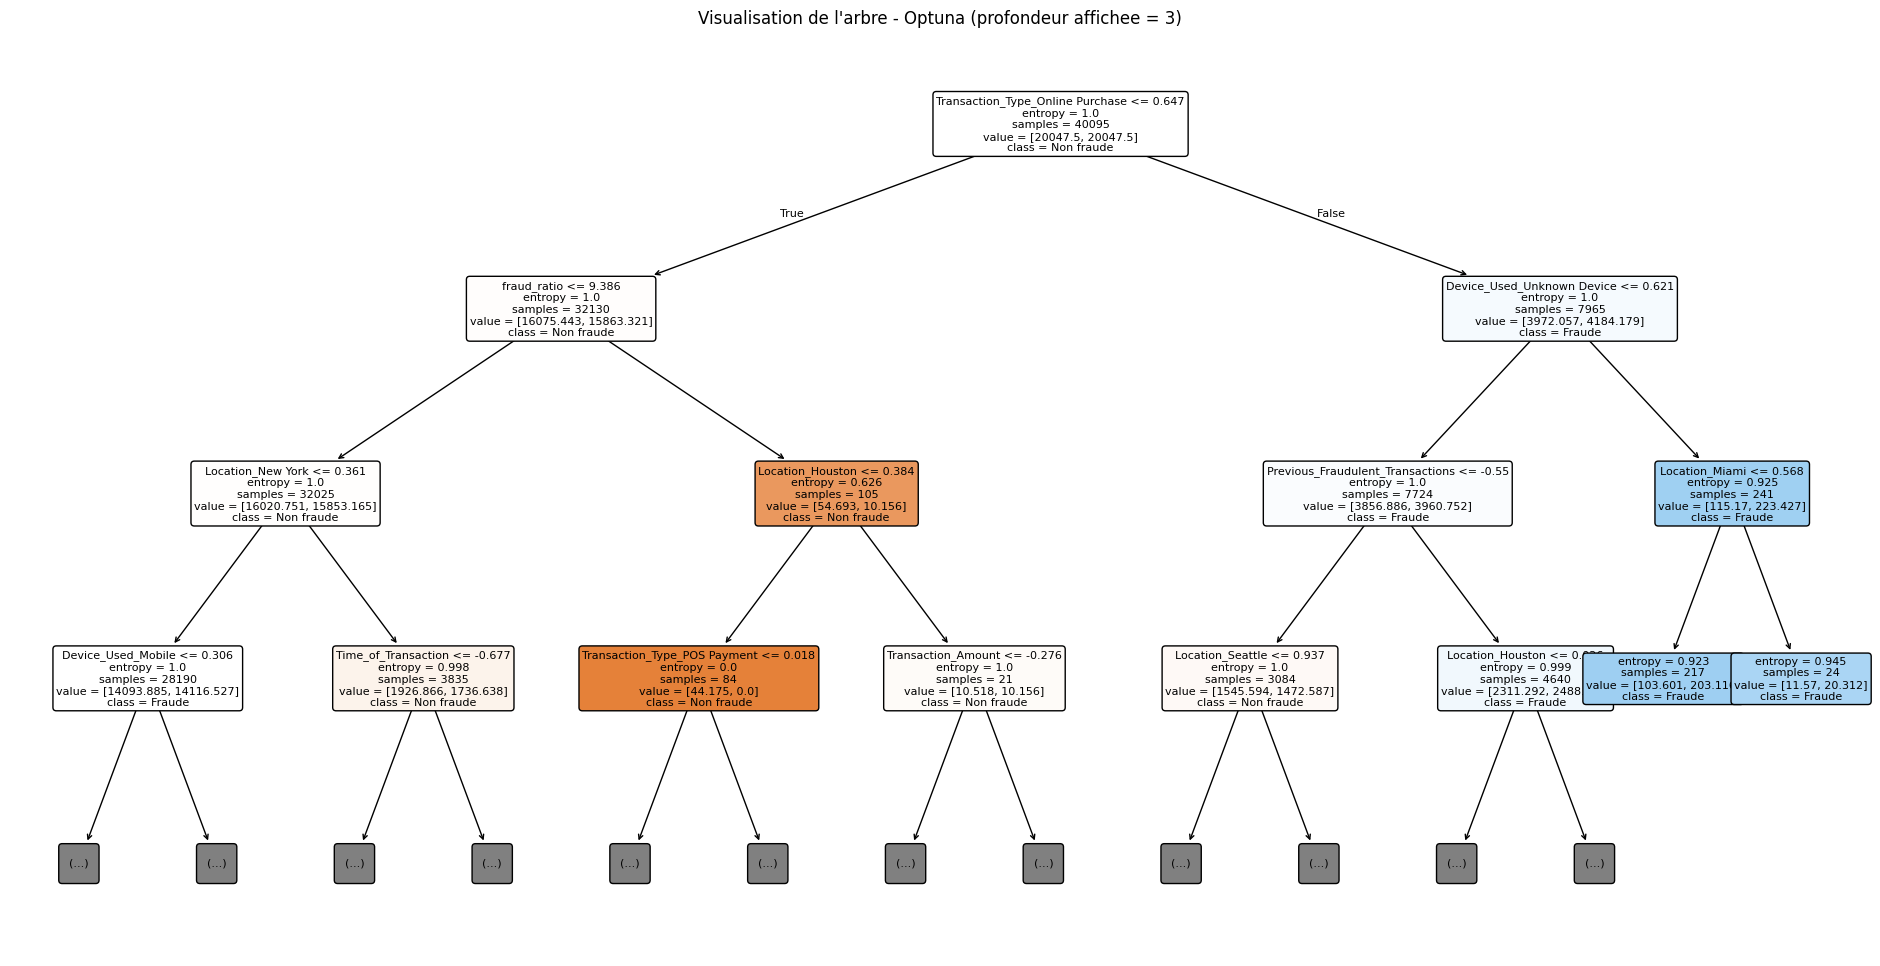

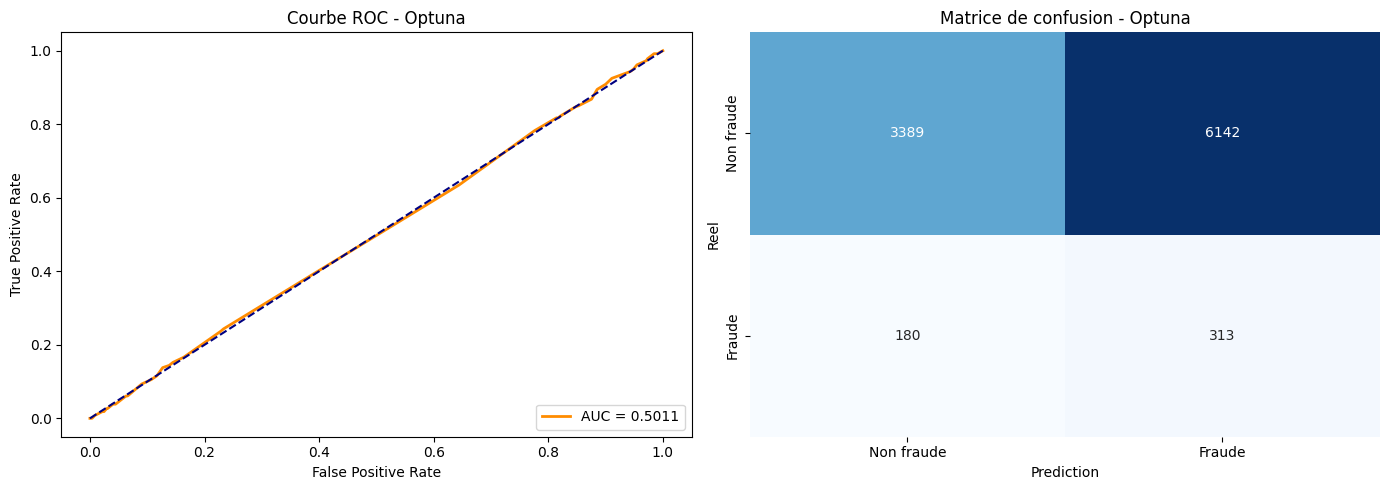

AUC score Optuna : 0.5011


0.501134761916011

In [36]:
optuna_model = DecisionTreeClassifier(**optuna_best_params)    
optuna_model.fit(X_train, y_train)
val_pred_optuna = optuna_model.predict(X_test)
val_proba_optuna = optuna_model.predict_proba(X_test)[:, 1]
auc_optuna = roc_auc_score(y_test, val_proba_optuna)


print("Meilleurs parametres Optuna:")
print(optuna_best_params)
print(f"Meilleure AUC CV: {optuna_best_cv_auc:.4f}")
print(f"AUC sur le jeu de test : {auc_optuna:.4f}")
draw_tree_model(optuna_model, X_train.columns, "Optuna", max_depth=3)
plot_auc_and_confusion(optuna_model, X_test, y_test, "Optuna")


> Même avec Optuna, les performances restent tres proches d'un comportement aleatoire. Cela renforce l'idee que la limite principale vient surtout des donnees disponibles et du faible pouvoir discriminant des variables actuelles, plus que du choix du modele lui-meme.

### Comparaison des methodes

Le graphique suivant permet de comparer rapidement les AUC obtenues par la baseline, RandomizedSearchCV et Optuna.

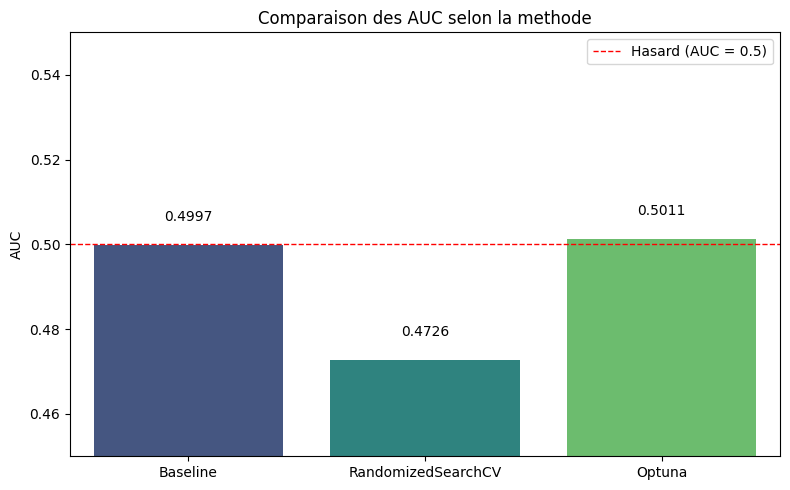

,Methode,AUC
0,Baseline,0.499737
1,RandomizedSearchCV,0.472601
2,Optuna,0.501135


In [37]:
comparison_df = pd.DataFrame({
    'Methode': ['Baseline', 'RandomizedSearchCV', 'Optuna'],
    'AUC': [auc_baseline, auc_randomized, auc_optuna]
})

plt.figure(figsize=(8, 5))
ax = sns.barplot(data=comparison_df, x='Methode', y='AUC', hue='Methode', palette='viridis', legend=False)
ax.axhline(0.5, color='red', linestyle='--', linewidth=1, label='Hasard (AUC = 0.5)')

for i, value in enumerate(comparison_df['AUC']):
    ax.text(i, value + 0.005, f'{value:.4f}', ha='center', va='bottom')

plt.ylim(0.45, max(0.55, comparison_df['AUC'].max() + 0.03))
plt.title('Comparaison des AUC selon la methode')
plt.ylabel('AUC')
plt.xlabel('')
plt.legend()
plt.tight_layout()
plt.show()

comparison_df

**Conclusion** : On remarque que notre arbre de decision n'arrive pas vraiment a distinguer les deux classes. Les scores restent tres proches d'un comportement aleatoire, ce qui va dans le meme sens que notre observation lors de l'analyse des boxplots : les distributions des deux classes se ressemblent beaucoup.

Cela suggere que la difficulte vient surtout des donnees disponibles. Avec les variables actuelles, le modele dispose de peu d'information pour separer clairement les transactions frauduleuses des transactions non frauduleuses.

Enfin, l'optimisation des hyperparametres avec RandomizedSearchCV et Optuna permet une legere amelioration, mais ce gain reste limite et ne change pas le constat principal.